# Survival Fairness Analysis - Clean Version

This notebook performs fairness analysis for survival models without Neptune dependencies.

**Expected directory structure:**
- Model: `MLEF/OS/C23/RWD/model.pkl` (trained Cox model)
- Test predictions: `MLEF/OS/C23/RWD/prediction_test.csv` (columns: Subject, EVENT, TIME, risk_score)
- External validation: `MLEF/OS/C23/RWD/prediction_external.csv` (columns: Subject, EVENT, TIME, risk_score)
- Clinical data: `../data/child23_imp_enc.xlsx` (contains demographic info: SEX, race columns)

**Analysis includes:**
1. C-index by medical center (test set)
2. C-index by race (external validation)
3. C-index by sex (test and external validation)
4. Bootstrap confidence intervals and statistical comparisons

In [1]:
from utils.helper_survival import *

In [2]:
# Configuration
BASE_PATH = Path('MLEF/OS/C23/RWD')
CLINICAL_DATA_PATH = Path('data/rwd.csv')
SITES = ['INT', 'GHD', 'VHIO', 'SZMC', 'MH']
N_BOOT = 1000
ALPHA = 0.05
SEED = 42

## Load Data and Clinical Information

In [3]:
# Load data
# If prediction files are CSV use load_predictions, otherwise read Excel directly.
# Using pd.read_excel here to avoid UnicodeDecodeError when files are .xlsx

test_predictions = pd.read_excel(BASE_PATH / 'prediction_TEST.xlsx')
external_predictions = pd.read_excel(BASE_PATH / 'prediction_EXVAL.xlsx')

clinical_data = load_clinical_data(CLINICAL_DATA_PATH)

print(f"Test set: {len(test_predictions)} patients")
print(f"External validation: {len(external_predictions)} patients")
print(f"Clinical data: {len(clinical_data)} patients")

FileNotFoundError: [Errno 2] No such file or directory: 'MLEF\\OS\\C23\\RWD\\prediction_TEST.xlsx'

## Calculate Fairness Analysis

In [ ]:
# Analysis by medical center
site_per_group, site_pairwise, site_overall_cindex = analyze_fairness_by_site(
    test_predictions, 
    SITES, 
    n_boot=N_BOOT, 
    seed=SEED
)


C-INDEX BY MEDICAL CENTER (Test Set)

INT      (n=102): 0.69 ± 0.06

INT      (n=102): 0.69 ± 0.06

GHD      (n= 65): 0.61 ± 0.10

GHD      (n= 65): 0.61 ± 0.10

VHIO     (n= 30): 0.57 ± 0.16

VHIO     (n= 30): 0.57 ± 0.16

SZMC     (n= 41): 0.67 ± 0.17

SZMC     (n= 41): 0.67 ± 0.17

MH       (n= 35): 0.50 ± 0.26

MH       (n= 35): 0.50 ± 0.26

Overall  (n=273): 0.66 ± 0.04

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
GHD vs MH      : diff=+0.110, p=0.4267, p_holm=1.0000 ns
GHD vs SZMC    : diff=-0.058, p=0.5611, p_holm=1.0000 ns
GHD vs VHIO    : diff=+0.033, p=0.7260, p_holm=1.0000 ns
INT vs GHD     : diff=+0.081, p=0.1523, p_holm=1.0000 ns
INT vs MH      : diff=+0.191, p=0.1512, p_holm=1.0000 ns
INT vs SZMC    : diff=+0.022, p=0.8085, p_holm=1.0000 ns
INT vs VHIO    : diff=+0.114, p=0.1893, p_holm=1.0000 ns
SZMC vs MH      : diff=+0.169, p=0.2920, p_holm=1.0000 ns
VH

In [ ]:
# Analysis by race
race_per_group, race_pairwise, race_overall_cindex = analyze_fairness_by_race(
    external_predictions,
    clinical_data,
    n_boot=N_BOOT,
    seed=SEED
)


C-INDEX BY RACE (External Validation)



Overall                        (n=251): 0.65 ± 0.05

Overall                        (n=251): 0.65 ± 0.05


KeyError: 'group'

In [ ]:
# Analysis by sex (test set)
sex_test_per_group, sex_test_pairwise, sex_test_overall_cindex = analyze_fairness_by_sex(
    test_predictions,
    clinical_data,
    set_name='test',
    n_boot=N_BOOT,
    seed=SEED
)


C-INDEX BY SEX (TEST Set)

Female   (n= 99): 0.70 ± 0.07

Female   (n= 99): 0.70 ± 0.07

Male     (n=174): 0.64 ± 0.05

Male     (n=174): 0.64 ± 0.05

Overall  (n=273): 0.66 ± 0.04

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
Female vs Male    : diff=+0.054, p=0.2195, p_holm=0.2195 ns

Overall  (n=273): 0.66 ± 0.04

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
Female vs Male    : diff=+0.054, p=0.2195, p_holm=0.2195 ns


In [ ]:
# Analysis by sex (external validation)
sex_ext_per_group, sex_ext_pairwise, sex_ext_overall_cindex = analyze_fairness_by_sex(
    external_predictions,
    clinical_data,
    set_name='external',
    n_boot=N_BOOT,
    seed=SEED
)


C-INDEX BY SEX (EXTERNAL Set)

Female   (n=148): 0.64 ± 0.07

Female   (n=148): 0.64 ± 0.07

Male     (n=103): 0.68 ± 0.08

Male     (n=103): 0.68 ± 0.08

Overall  (n=251): 0.65 ± 0.05

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
Female vs Male    : diff=-0.045, p=0.3944, p_holm=0.3944 ns

Overall  (n=251): 0.65 ± 0.05

------------------------------------------------------------
Pairwise Comparisons (Holm-corrected):
------------------------------------------------------------
Female vs Male    : diff=-0.045, p=0.3944, p_holm=0.3944 ns


## Plots

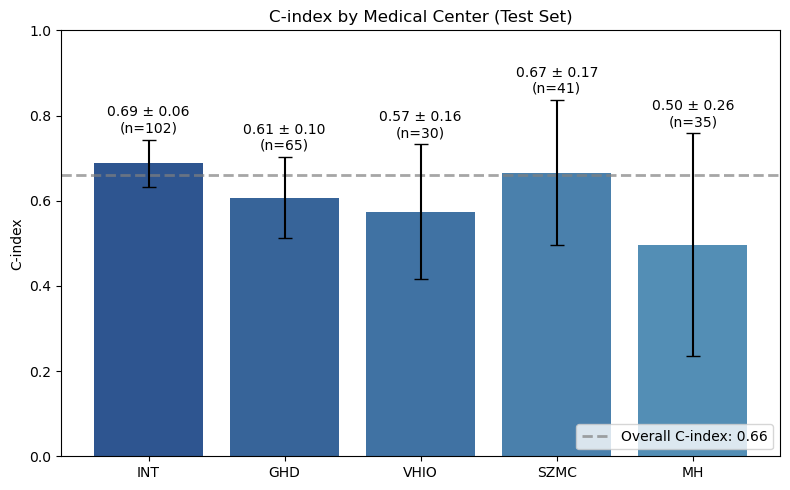

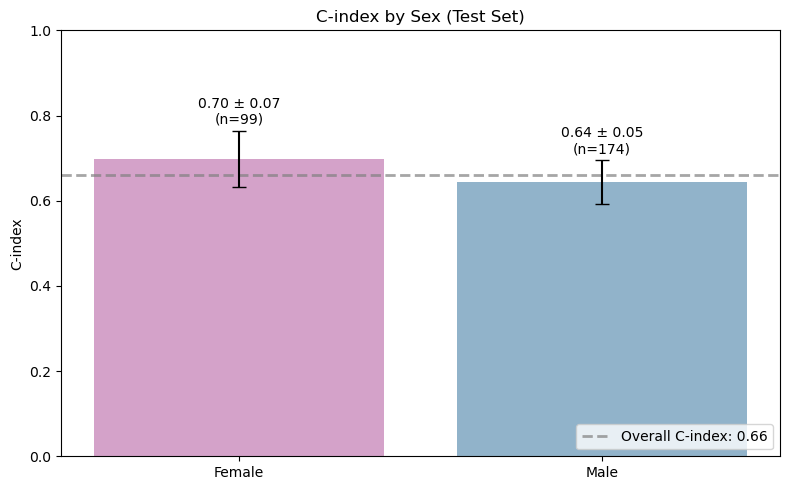

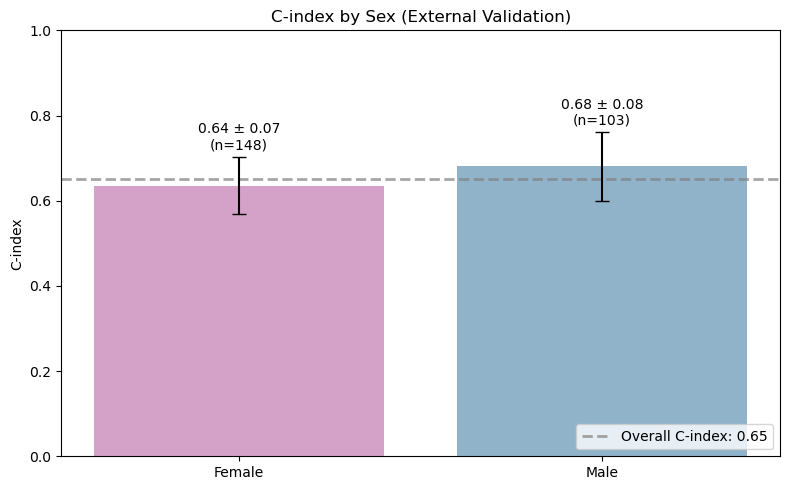

In [ ]:
# Plot results
fig1 = plot_fairness_results(
    site_per_group, 
    'C-index by Medical Center (Test Set)', 
    group_order=['INT', 'GHD', 'VHIO', 'SZMC', 'MH'],
    overall_cindex=site_overall_cindex
)
if fig1:
    #fig1.savefig('../supplementary/survival_cindex_per_site.png', dpi=600)
    plt.show()

# fig2 = plot_fairness_results(
#     race_per_group, 
#     'C-index by Race (External Validation)', 
#     palette=["#1E52A0", '#4292C6'],
#     overall_cindex=race_overall_cindex
# )
# if fig2:
#     #fig2.savefig('../supplementary/survival_cindex_per_race.png', dpi=600)
#     plt.show()

fig3 = plot_fairness_results(
    sex_test_per_group, 
    'C-index by Sex (Test Set)', 
    palette=["#dc9ace", '#88b5d3'],
    overall_cindex=sex_test_overall_cindex
)
if fig3:
    #fig3.savefig('../supplementary/survival_cindex_test_per_sex.png', dpi=600)
    plt.show()

fig4 = plot_fairness_results(
    sex_ext_per_group, 
    'C-index by Sex (External Validation)', 
    palette=["#dc9ace", '#88b5d3'],
    overall_cindex=sex_ext_overall_cindex
)
if fig4:
    #fig4.savefig('../supplementary/survival_cindex_ext_per_sex.png', dpi=600)
    plt.show()